## Step 1: Environment and data check

Proposal: use **80–120 paired images** from LOL-v2 Real. We verify pair count and that images load.

In [2]:
# Ensure package is importable: run from final-project root after: pip install -e .
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "low").exists():
    PROJECT_ROOT = PROJECT_ROOT / "final-project"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from lowlight.config import DATA_DIR, MAX_PAIRS, MIN_PAIRS
from lowlight.data import discover_pairs, load_image

pairs, low_only, normal_only = discover_pairs(str(DATA_DIR))
n_pairs = len(pairs)
print(f"Total pairs: {n_pairs} (required: {MIN_PAIRS}–{MAX_PAIRS})")
print(f"OK: {MIN_PAIRS <= n_pairs <= MAX_PAIRS}")

if pairs:
    path_low, path_normal = pairs[0]
    sh_low = load_image(path_low).shape
    sh_norm = load_image(path_normal).shape
    print(f"Sample low shape: {sh_low}, normal shape: {sh_norm}")

Total pairs: 100 (required: 80–120)
OK: True
Sample low shape: (400, 600, 3), normal shape: (400, 600, 3)


## Milestone 1: Preprocessing (Proposal §3)

- **Resize:** standardize to 256×256.
- **Normalize:** scale pixel values to [0, 1].
- **Optional augmentation:** horizontal flip or small rotation (we use False by default; enable for training if justified in report).

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from lowlight.config import DATA_DIR, IMAGE_SIZE
from lowlight.data import load_dataset
from lowlight.utils import plot_pair

low_imgs, normal_imgs, pair_paths = load_dataset(
    str(DATA_DIR),
    target_size=IMAGE_SIZE,
    normalize=True,
    augment=False,
    seed=42,
)

print(f"Low images:    {low_imgs.shape}   dtype={low_imgs.dtype}   range=[{low_imgs.min():.2f}, {low_imgs.max():.2f}]")
print(f"Normal images: {normal_imgs.shape}   dtype={normal_imgs.dtype}   range=[{normal_imgs.min():.2f}, {normal_imgs.max():.2f}]")

Low images:    (100, 256, 256, 3)   dtype=float64   range=[0.00, 1.00]
Normal images: (100, 256, 256, 3)   dtype=float64   range=[0.00, 1.00]


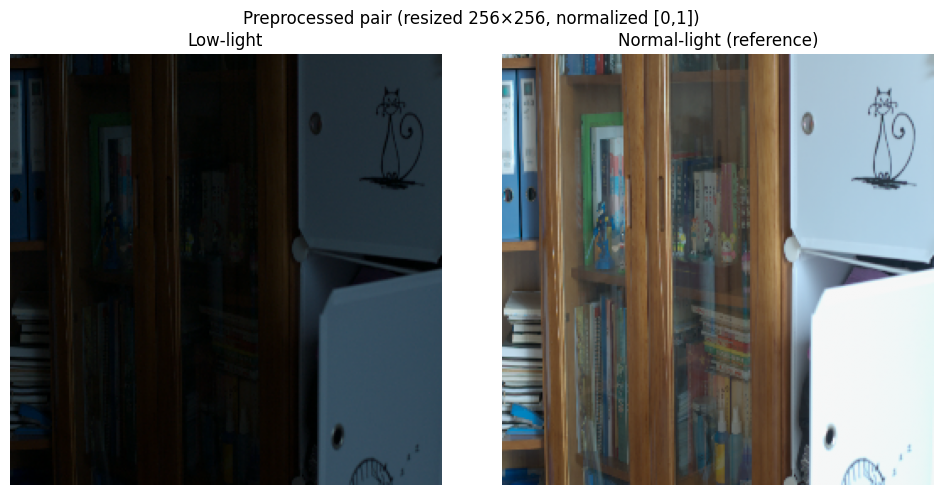

In [4]:
# Visual check: one pair (low vs normal)
plot_pair(low_imgs[0], normal_imgs[0], title="Preprocessed pair (resized 256×256, normalized [0,1])")

## Phase 1: Image Quality Analysis and Classification (Proposal §4.1)

**Objective:** Analyze statistical differences between low-light and normal-light images using **handcrafted features** and train a **binary classifier** (Low vs Normal).

**Features (from grayscale):** Mean intensity, Standard deviation (contrast), Entropy, Histogram skewness.  
**Classifier:** Logistic Regression or SVM (no deep learning in this phase).  
**Metrics:** Accuracy, Precision, Recall, F1-score, Confusion matrix.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from lowlight.features import extract_features_batch

# Extract handcrafted features from grayscale (Proposal §4.1: mean, std, entropy, skewness)
X_low = extract_features_batch(low_imgs)      # (N, 4)
X_normal = extract_features_batch(normal_imgs) # (N, 4)
X = np.vstack([X_low, X_normal])
y = np.array([0] * len(low_imgs) + [1] * len(normal_imgs))  # 0 = low-light, 1 = normal-light

# Train/test split (same split can be used for Phase 2/3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training samples: {len(y_train)}, Test samples: {len(y_test)}")
print(f"Feature matrix shape: {X.shape} (samples, features)")

Training samples: 160, Test samples: 40
Feature matrix shape: (200, 4) (samples, features)


In [6]:
# Train binary classifier (Proposal: Logistic Regression or SVM only; no deep learning)
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Evaluation metrics (Proposal §4.1)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Low-light", "Normal-light"]))
print("Metrics summary:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-score:  {f1:.4f}")

Classification Report:
              precision    recall  f1-score   support

   Low-light       1.00      1.00      1.00        20
Normal-light       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

Metrics summary:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-score:  1.0000


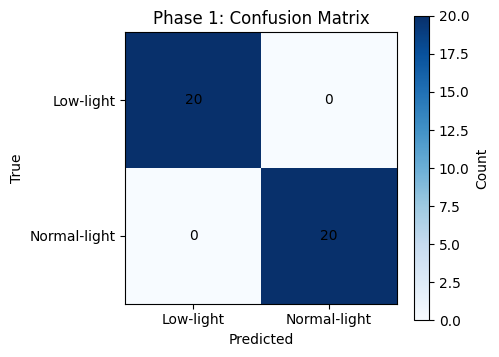

In [7]:
# Confusion matrix visualization (Proposal §4.1 deliverable)
from lowlight.config import FIGURES_DIR
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Low-light", "Normal-light"])
ax.set_yticklabels(["Low-light", "Normal-light"])
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")
plt.colorbar(im, ax=ax, label="Count")
plt.title("Phase 1: Confusion Matrix")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase1_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Save trained classifier (Phase 1 deliverable) for report/reuse
from lowlight.config import MODELS_DIR
import joblib
MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(clf, MODELS_DIR / "phase1_classifier.joblib")
print(f"Classifier saved to {MODELS_DIR / 'phase1_classifier.joblib'}")

Classifier saved to /home/saeedm/Documents/image-processing/final-project/models/phase1_classifier.joblib


## Phase 2: Image Enhancement (Proposal §4.2)

**Part A – Classical methods:** At least three of: Histogram Equalization, CLAHE, Gamma Correction, Single-Scale Retinex (SSR).  
**Part B – Lightweight autoencoder:** 3–4 conv layers, MSE loss only, 20–30 epochs. No GANs or perceptual loss.

In [9]:
# Pair-level train/test split for Phase 2 & 3 (same random_state for reproducibility)
from sklearn.model_selection import train_test_split
n_pairs = len(low_imgs)
pair_idx = np.arange(n_pairs)
train_idx, test_idx = train_test_split(pair_idx, test_size=0.2, random_state=42)
low_train, low_test = low_imgs[train_idx], low_imgs[test_idx]
normal_train, normal_test = normal_imgs[train_idx], normal_imgs[test_idx]
print(f"Train pairs: {len(train_idx)}, Test pairs: {len(test_idx)}")

Train pairs: 80, Test pairs: 20


In [10]:
# Phase 2A: Classical enhancement methods (Proposal §4.2 Part A)
from lowlight.enhancement import enhance_histogram_equalization, enhance_clahe, enhance_gamma, enhance_ssr

def apply_to_batch(imgs, enhance_fn, **kwargs):
    return np.array([enhance_fn(imgs[i], **kwargs) if kwargs else enhance_fn(imgs[i]) for i in range(len(imgs))])

# Apply all four classical methods to test set
enhanced_he   = apply_to_batch(low_test, enhance_histogram_equalization)
enhanced_clahe = apply_to_batch(low_test, enhance_clahe)
enhanced_gamma = apply_to_batch(low_test, enhance_gamma, gamma=2.0)  # Proposal: parameter sensitivity analysis
enhanced_ssr  = apply_to_batch(low_test, enhance_ssr, sigma=30.0)

print("Classical enhancements applied. Shapes:", enhanced_he.shape, enhanced_clahe.shape, enhanced_gamma.shape, enhanced_ssr.shape)

Classical enhancements applied. Shapes: (20, 256, 256, 3) (20, 256, 256, 3) (20, 256, 256, 3) (20, 256, 256, 3)


In [11]:
# Phase 2B: Lightweight autoencoder (Proposal §4.2 Part B – MSE only, 20–30 epochs)
from lowlight.config import AE_EPOCHS, MODELS_DIR
from lowlight.enhancement.autoencoder import train_autoencoder, predict_autoencoder, save_autoencoder

ae_model, ae_losses = train_autoencoder(
    low_train, normal_train,
    epochs=AE_EPOCHS,
    lr=1e-3,
    batch_size=8,
)
print(f"Autoencoder trained for {AE_EPOCHS} epochs. Final loss: {ae_losses[-1]:.6f}")

Autoencoder trained for 25 epochs. Final loss: 0.017630


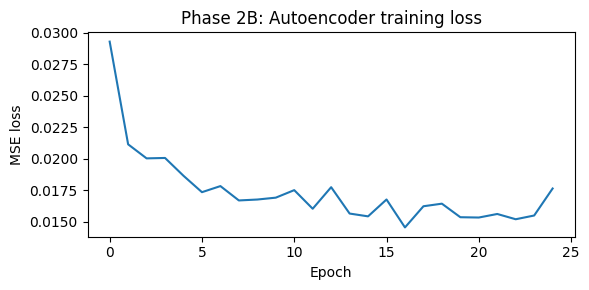

In [12]:
# Plot training loss
plt.figure(figsize=(6, 3))
plt.plot(ae_losses, color="tab:blue")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Phase 2B: Autoencoder training loss")
plt.tight_layout()
plt.show()

In [13]:
# Predict on test set and save model
enhanced_ae = predict_autoencoder(ae_model, low_test)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
save_autoencoder(ae_model, str(MODELS_DIR / "phase2_autoencoder.pt"))
print(f"Enhanced test set shape: {enhanced_ae.shape}. Model saved to {MODELS_DIR / 'phase2_autoencoder.pt'}")

Enhanced test set shape: (20, 256, 256, 3). Model saved to /home/saeedm/Documents/image-processing/final-project/models/phase2_autoencoder.pt


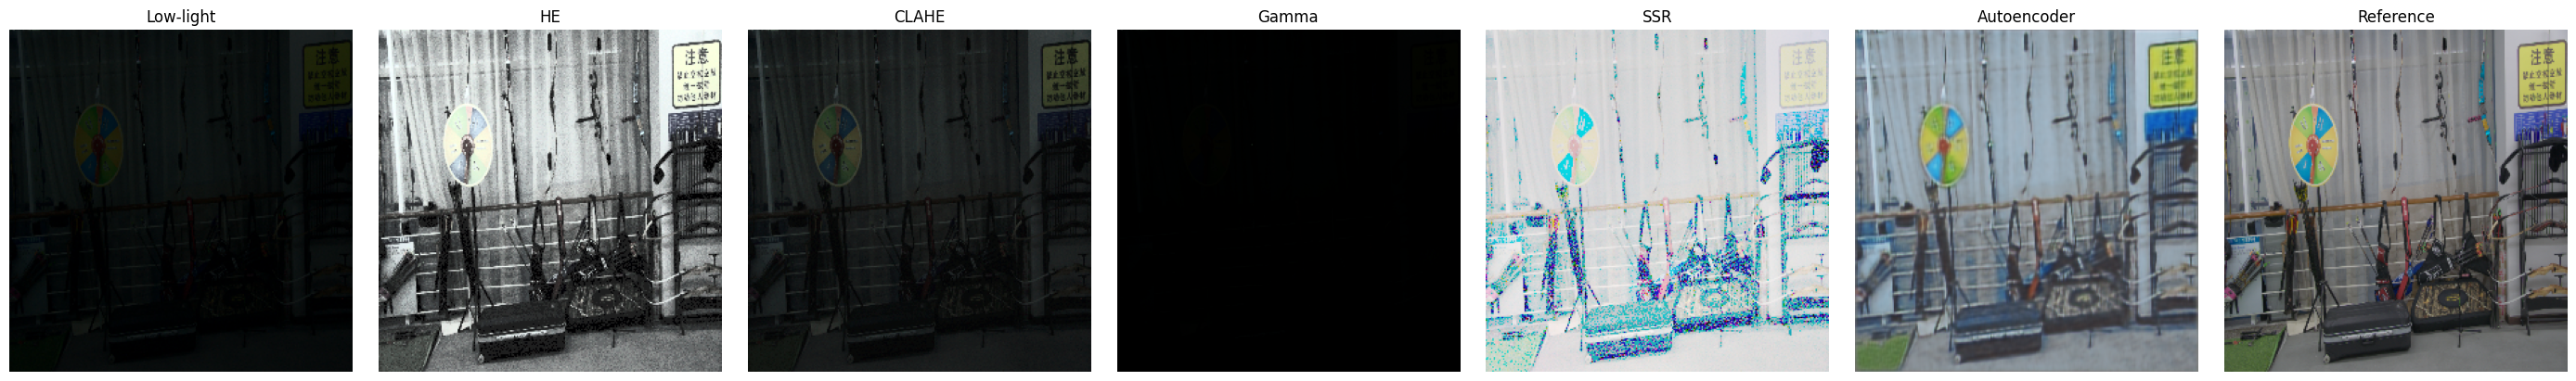

In [20]:
# Visual comparison: one test image – low | HE | CLAHE | Gamma | SSR | AE | reference
from lowlight.config import FIGURES_DIR
from lowlight.utils import plot_enhancement_comparison
idx = 0
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plot_enhancement_comparison(
    low_test[idx],
    [enhanced_he[idx], enhanced_clahe[idx], enhanced_gamma[idx], enhanced_ssr[idx], enhanced_ae[idx]],
    normal_test[idx],
    ["HE", "CLAHE", "Gamma", "SSR", "Autoencoder"],
    save_path=str(FIGURES_DIR / "phase2_comparison.png"),
)

## Phase 3: Quantitative and Qualitative Evaluation (Proposal §4.3)

**Metrics:** PSNR and SSIM (proposal formulas). Reported for: **original low-light**, each **enhancement method**, and **autoencoder** output (all vs. normal-light reference).

**Deliverables:** Tables (mean ± std), bar charts comparing methods, and visual comparisons (input vs enhanced vs reference).

In [21]:
# Compute PSNR and SSIM for each method (Proposal §4.3)
from lowlight.evaluation import psnr, ssim

def compute_metrics_per_image(enhanced_imgs, reference_imgs):
    """enhanced_imgs, reference_imgs: (N, H, W, C). Returns arrays of length N."""
    return (
        np.array([psnr(enhanced_imgs[i], reference_imgs[i]) for i in range(len(enhanced_imgs))]),
        np.array([ssim(enhanced_imgs[i], reference_imgs[i]) for i in range(len(enhanced_imgs))]),
    )

# Reference = normal_test for all
methods = ["Original (low-light)", "Histogram Eq.", "CLAHE", "Gamma", "SSR", "Autoencoder"]
all_enhanced = [low_test, enhanced_he, enhanced_clahe, enhanced_gamma, enhanced_ssr, enhanced_ae]
psnr_means, psnr_stds = [], []
ssim_means, ssim_stds = [], []
for name, imgs in zip(methods, all_enhanced):
    p, s = compute_metrics_per_image(imgs, normal_test)
    psnr_means.append(np.mean(p))
    psnr_stds.append(np.std(p))
    ssim_means.append(np.mean(s))
    ssim_stds.append(np.std(s))
print("Metrics computed for all methods.")

Metrics computed for all methods.


In [22]:
# Results table (Proposal §4.3 deliverable)
import pandas as pd
results = pd.DataFrame({
    "Method": methods,
    "PSNR (dB)": [f"{m:.2f} ± {sd:.2f}" for m, sd in zip(psnr_means, psnr_stds)],
    "SSIM": [f"{m:.4f} ± {sd:.4f}" for m, sd in zip(ssim_means, ssim_stds)],
})
results

,Method,PSNR (dB),SSIM
0,Original (low-light),6.15 ± 1.51,0.1098 ± 0.0833
1,Histogram Eq.,16.76 ± 2.54,0.5520 ± 0.1622
2,CLAHE,7.19 ± 1.88,0.2583 ± 0.1416
3,Gamma,5.29 ± 1.21,0.0094 ± 0.0106
4,SSR,10.64 ± 2.18,0.5210 ± 0.1057
5,Autoencoder,17.23 ± 2.97,0.7825 ± 0.0723


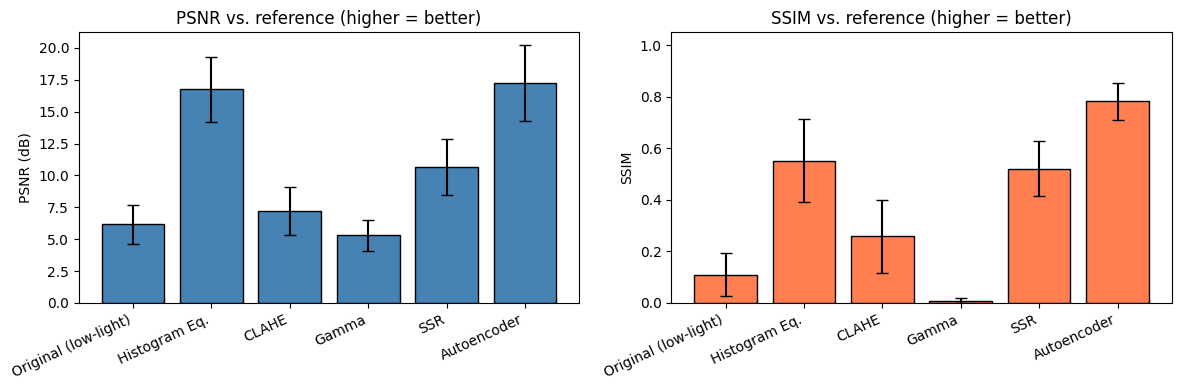

Bar charts saved to /home/saeedm/Documents/image-processing/final-project/figures/phase3_psnr_ssim_bars.png


In [23]:
# Bar charts: PSNR and SSIM across methods (Proposal §4.3)
from lowlight.config import FIGURES_DIR
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(methods))
axes[0].bar(x, psnr_means, yerr=psnr_stds, capsize=4, color="steelblue", edgecolor="black")
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, rotation=25, ha="right")
axes[0].set_ylabel("PSNR (dB)")
axes[0].set_title("PSNR vs. reference (higher = better)")
axes[0].set_ylim(bottom=0)
axes[1].bar(x, ssim_means, yerr=ssim_stds, capsize=4, color="coral", edgecolor="black")
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods, rotation=25, ha="right")
axes[1].set_ylabel("SSIM")
axes[1].set_title("SSIM vs. reference (higher = better)")
axes[1].set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase3_psnr_ssim_bars.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Bar charts saved to {FIGURES_DIR / 'phase3_psnr_ssim_bars.png'}")

### Analysis and Discussion (Proposal §5 – critical for grading)

Address these in your **report** (heavily weighted):

1. **Why can higher PSNR sometimes correspond to worse visual quality?** (e.g. PSNR is pixel-wise; oversmoothing or slight misalignment can change PSNR without matching perception.)
2. **In which scenarios do classical methods outperform the autoencoder?** (e.g. when training data is limited, or when the scene is very dark / noisy.)
3. **What is the trade-off between brightness enhancement and noise amplification?** (e.g. HE/CLAHE can amplify noise; gamma may preserve it differently.)
4. **Is increased brightness always equivalent to better image quality?** (No – overexposure, loss of detail, or unnatural look can reduce quality.)

---
## Summary and Deliverables

This notebook produces all required outputs for the BSc project:

- **Phase 1:** Feature extraction, trained classifier, evaluation table, confusion matrix → `figures/phase1_confusion_matrix.png`, `models/phase1_classifier.joblib`
- **Phase 2:** Classical methods (HE, CLAHE, Gamma, SSR) + autoencoder → `figures/phase2_comparison.png`, `models/phase2_autoencoder.pt`
- **Phase 3:** PSNR/SSIM table and bar charts → `figures/phase3_psnr_ssim_bars.png`

**Submission:** Run the notebook from top to bottom (Kernel → Restart & Run All), then submit this notebook, the report (8–10 pages), and the contents of `figures/`.